# Gradient Flow Population Validation

Validate numerically that $\mu(t) \to 0$ under approximate population gradient flow for 1D 2-class Gaussian data, a 2-ReLU hidden-layer NN, and an LDA head with trainable class means $\pm \mu$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def sample_population(N, m):
    rng = np.random.default_rng()
    y = rng.choice([-1.0, 1.0], size=N)  # equal priors
    x = y * m + rng.standard_normal(size=N)  # variance 1
    return x, y


def relu(u):
    return np.maximum(u, 0.0)


def forward(x, params):
    # params: v1,v2,w1,w2,b1,b2,c
    v1, v2, w1, w2, b1, b2, c = params
    s1 = w1 * x + b1
    s2 = w2 * x + b2
    h1 = relu(s1)
    h2 = relu(s2)
    f = v1 * h1 + v2 * h2 + c
    cache = (s1, s2, h1, h2)
    return f, cache


def gradients(x, y, mu, params):
    """
    Population-gradient estimator for gradient ascent on:
        L = const - 0.5 * E[(f - y*mu)^2]
    Using r = y*mu - f.

    Returns:
        dmu (scalar), dparams (shape (7,))
    """
    v1, v2, w1, w2, b1, b2, c = params
    f, (s1, s2, h1, h2) = forward(x, params)
    r = y * mu - f

    # dL/dmu = E[y f] - mu  (equivalently E[y*(f - y*mu)])
    dmu = np.mean(y * f) - mu

    # For parameters: dL/dp = E[ r * df/dp ]
    ind1 = (s1 > 0.0).astype(float)
    ind2 = (s2 > 0.0).astype(float)

    df_dv1 = h1
    df_dv2 = h2
    df_dw1 = v1 * ind1 * x
    df_dw2 = v2 * ind2 * x
    df_db1 = v1 * ind1
    df_db2 = v2 * ind2
    df_dc = np.ones_like(x)

    dparams = np.array([
        np.mean(r * df_dv1),
        np.mean(r * df_dv2),
        np.mean(r * df_dw1),
        np.mean(r * df_dw2),
        np.mean(r * df_db1),
        np.mean(r * df_db2),
        np.mean(r * df_dc),
    ])

    return dmu, dparams



In [2]:
def run(m=2.0, N=200_000, steps=20_000, lr_mu=0.02, lr_theta=0.02, track_every=100):
    # Big Monte Carlo sample ~ population expectation
    x, y = sample_population(N=N, m=m)

    rng = np.random.default_rng()

    # Initialize parameters small-ish
    params = rng.normal(scale=0.2, size=7).astype(float)
    # Optionally start with c=0 to avoid early bias drift (not required)
    params[-1] = 0.0

    mu = 1.0  # start nonzero

    mu_hist = np.empty(steps, dtype=float)
    L_hist = np.empty(steps, dtype=float)
    Eyf_hist = np.empty(steps, dtype=float)
    params_hist = np.empty((steps, 7), dtype=float)

    # Distribution tracking for f_w(X): keep snapshots every `track_every` steps
    fw_snapshots = []
    fw_snapshot_steps = []

    for t in range(steps):
        # Compute gradients (population approx)
        dmu, dparams = gradients(x, y, mu, params)

        # Euler step for gradient ascent on L
        mu = mu + lr_mu * dmu
        params = params + lr_theta * dparams

        # Track
        f, _ = forward(x, params)
        Eyf = np.mean(y * f)
        # log-likelihood up to constant:
        L = -0.5 * np.mean((f - y * mu) ** 2)

        mu_hist[t] = mu
        L_hist[t] = L
        Eyf_hist[t] = Eyf
        params_hist[t] = params

        # Save distribution snapshots every `track_every` iterations
        if (t + 1) % track_every == 0:
            fw_snapshots.append(f.copy())
            fw_snapshot_steps.append(t + 1)

        # light logging
        if (t + 1) % (steps // 10) == 0:
            print(f"step {t+1:6d}/{steps} | mu={mu:+.6f} | E[Yf]={Eyf:+.6f} | L={L:+.6f}")

    return mu, params, mu_hist, L_hist, Eyf_hist, params_hist, fw_snapshots, fw_snapshot_steps



Running with m=2.0
step   1000/10000 | mu=+0.058990 | E[Yf]=+0.057085 | L=-0.000416
step   2000/10000 | mu=+0.034371 | E[Yf]=+0.033569 | L=-0.000126
step   3000/10000 | mu=+0.022274 | E[Yf]=+0.021811 | L=-0.000051
step   4000/10000 | mu=+0.014504 | E[Yf]=+0.014169 | L=-0.000023
step   5000/10000 | mu=+0.008299 | E[Yf]=+0.008013 | L=-0.000009
step   6000/10000 | mu=+0.003799 | E[Yf]=+0.003647 | L=-0.000003
step   7000/10000 | mu=+0.001800 | E[Yf]=+0.001739 | L=-0.000002
step   8000/10000 | mu=+0.000973 | E[Yf]=+0.000947 | L=-0.000001
step   9000/10000 | mu=+0.000610 | E[Yf]=+0.000598 | L=-0.000001
step  10000/10000 | mu=+0.000433 | E[Yf]=+0.000427 | L=-0.000001
Final mu (m=2.0): +0.00043340
Final E[Yf] (m=2.0): +0.00042708


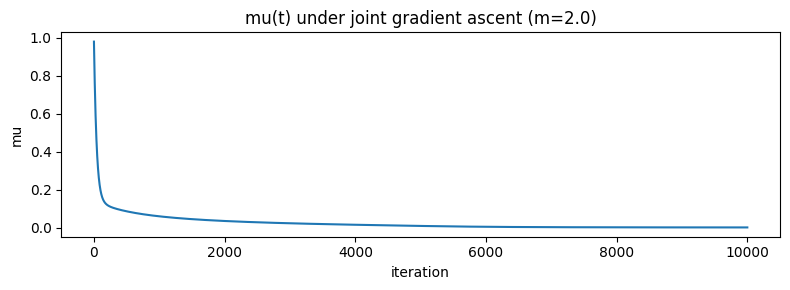

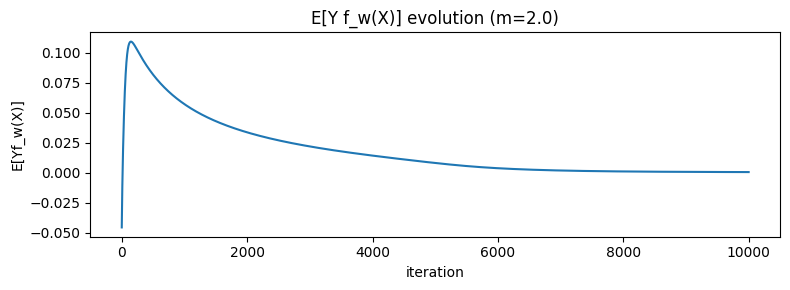

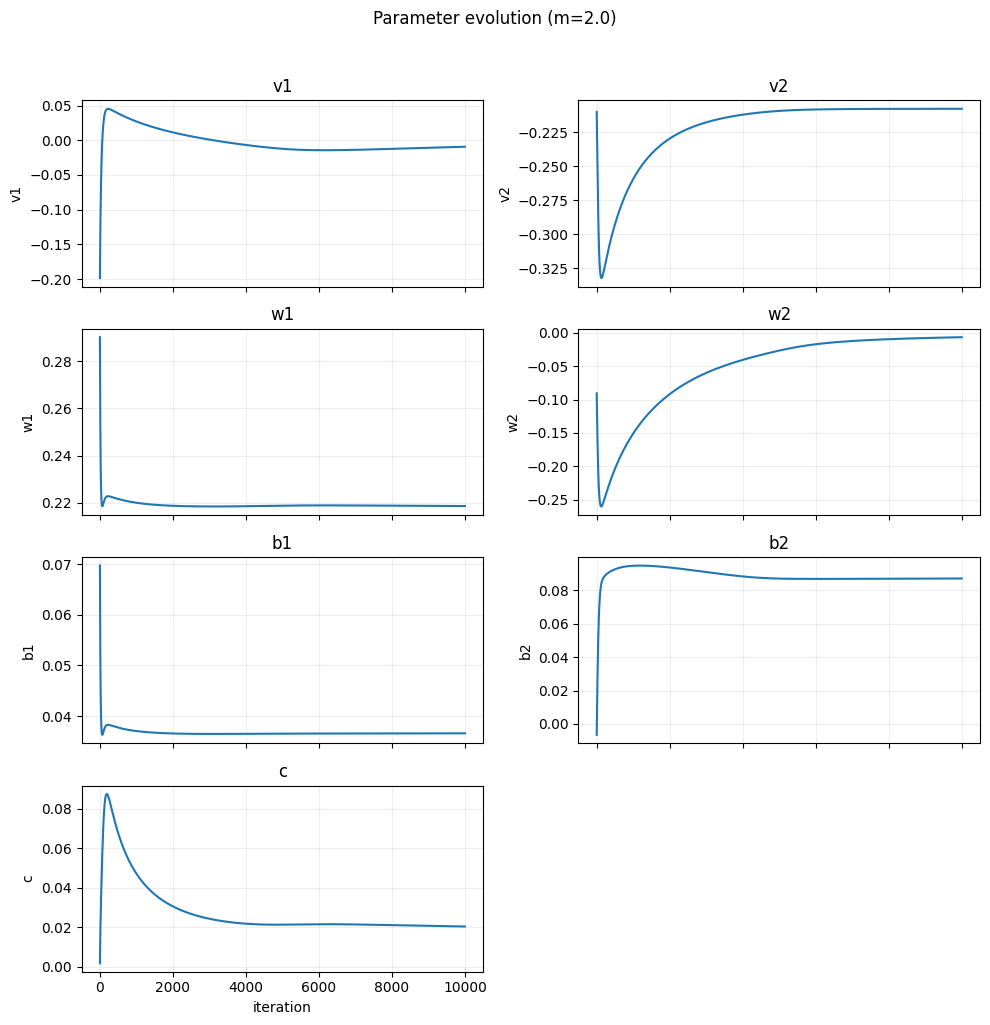

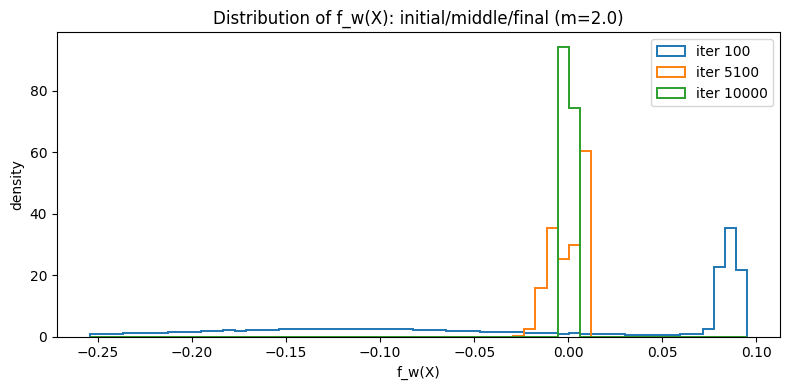

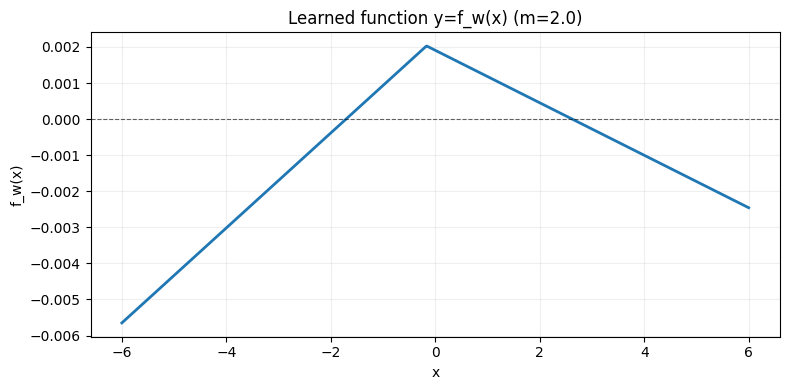

In [3]:
# Run only m=2.0 and plot parameter evolution
m = 2.0
print("" + "=" * 60)
print(f"Running with m={m}")
mu_final, params_final, mu_hist, L_hist, Eyf_hist, params_hist, fw_snapshots, fw_snapshot_steps = run(
    m=m,
    N=200_000,
    steps=10_000,
    lr_mu=0.02,
    lr_theta=0.02,
    track_every=100,
)
print(f"Final mu (m={m}): {mu_final:+.8f}")
print(f"Final E[Yf] (m={m}): {Eyf_hist[-1]:+.8f}")

param_names = ["v1", "v2", "w1", "w2", "b1", "b2", "c"]

# Plot mu(t)
plt.figure(figsize=(8, 3))
plt.plot(mu_hist)
plt.xlabel("iteration")
plt.ylabel("mu")
plt.title(f"mu(t) under joint gradient ascent (m={m})")
plt.tight_layout()

# Plot E[Y f_w(X)]
plt.figure(figsize=(8, 3))
plt.plot(Eyf_hist)
plt.xlabel("iteration")
plt.ylabel("E[Yf_w(X)]")
plt.title(f"E[Y f_w(X)] evolution (m={m})")
plt.tight_layout()

# Plot all other parameters over time
fig, axes = plt.subplots(4, 2, figsize=(10, 10), sharex=True)
axes = axes.ravel()
for i, name in enumerate(param_names):
    axes[i].plot(params_hist[:, i])
    axes[i].set_title(name)
    axes[i].set_ylabel(name)
    axes[i].grid(alpha=0.2)

axes[-1].axis("off")
axes[6].set_xlabel("iteration")
plt.suptitle(f"Parameter evolution (m={m})", y=1.02)
plt.tight_layout()

# Plot tracked distributions of f_w(X): initial, middle, final snapshot
if fw_snapshots:
    if len(fw_snapshots) == 1:
        show_idx = np.array([0], dtype=int)
    elif len(fw_snapshots) == 2:
        show_idx = np.array([0, 1], dtype=int)
    else:
        show_idx = np.array([0, len(fw_snapshots) // 2, len(fw_snapshots) - 1], dtype=int)

    # Use shared bins across selected snapshots for comparability
    selected = [fw_snapshots[i] for i in show_idx]
    all_vals = np.concatenate(selected)
    bins = np.linspace(np.percentile(all_vals, 1), np.percentile(all_vals, 99), 60)

    plt.figure(figsize=(8, 4))
    for i in show_idx:
        plt.hist(
            fw_snapshots[i],
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.4,
            label=f"iter {fw_snapshot_steps[i]}",
        )
    plt.xlabel("f_w(X)")
    plt.ylabel("density")
    plt.title(f"Distribution of f_w(X): initial/middle/final (m={m})")
    plt.legend()
    plt.tight_layout()

# Plot learned function y = f_w(x)
x_grid = np.linspace(-6, 6, 800)
y_grid, _ = forward(x_grid, params_final)

plt.figure(figsize=(8, 4))
plt.plot(x_grid, y_grid, linewidth=2.0)
plt.axhline(0.0, color="k", linestyle="--", linewidth=0.8, alpha=0.6)
plt.xlabel("x")
plt.ylabel("f_w(x)")
plt.title(f"Learned function y=f_w(x) (m={m})")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()


